In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# importing the libararies 

In [ ]:
df=pd.read_csv('Social_Network_Ads.csv')
#Downlodad from kaggle

In [4]:
df.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df=df.drop(['User ID','Gender'],axis=1)
#Here i am removing the unwanted columns from my dataset

In [9]:
df.head(5)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
x=df.drop('Purchased',axis=1)
y=df['Purchased']
# Here we are seperating the input and output columns in x and y sumiltaneously

In [24]:
from sklearn.model_selection import train_test_split
# calling function for train test split and seperating data for tranning and testing
x_train,x_test,y_train,y_test= train_test_split( x,y,test_size=0.2,random_state=42)



In [25]:
x_train.shape,x_test.shape

((320, 2), (80, 2))

In [26]:
from sklearn.preprocessing import StandardScaler
# StandardScaler will apply the formula xi=(xi'-x')/standard diviation and scale down the value 
# Here xi=new coln for scale valu,xi'= value,x'=mean of the coln

scaler=StandardScaler()
scaler.fit(x_train)

x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)
# Here we are converting the x_train_scale & X_test_scale in a pandas dataframe 
# becacuse the standatdscalar class give us the result in a numpy array

In [ ]:
x_train_scaled.head(5),x_train_scaled.head(5)
# Now we can see we got the scaled value of both tranning and testing data 

(        Age  EstimatedSalary
 0 -1.066752        -0.386344
 1  0.797535        -1.229939
 2  0.110692         1.853544
 3  0.601294        -0.909955
 4  1.876859        -1.288118,
         Age  EstimatedSalary
 0 -1.066752        -0.386344
 1  0.797535        -1.229939
 2  0.110692         1.853544
 3  0.601294        -0.909955
 4  1.876859        -1.288118)

Text(0.5, 1.0, 'After scelling')

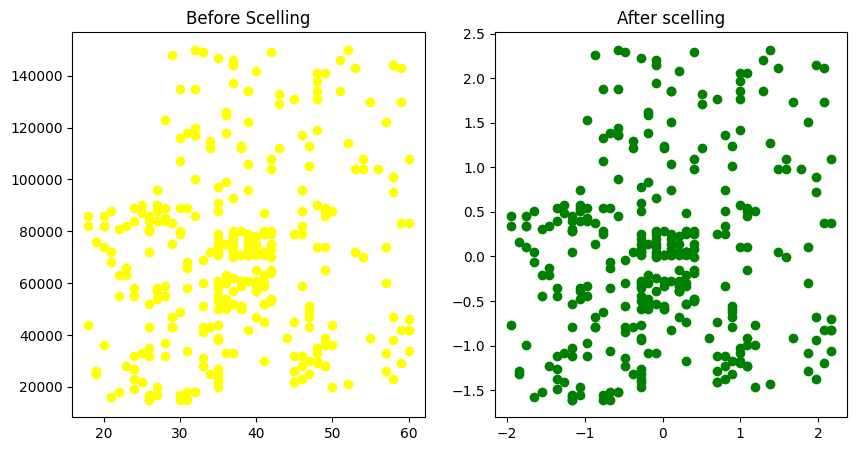

In [ ]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(10,5))
# we are simply ploting the before and af after result of the data in a scatter plot
ax1.scatter(x_train['Age'],x_train['EstimatedSalary'],color='yellow')
ax1.set_title("Before Scelling")
ax2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color='green')
ax2.set_title("After scelling")

# Here we can see that the scalling dosenot affect the true nature of the data 
# IT simply scale down the value of the Data
# our data is just centered


<Axes: title={'center': 'After Scelling'}, xlabel='Age', ylabel='Density'>

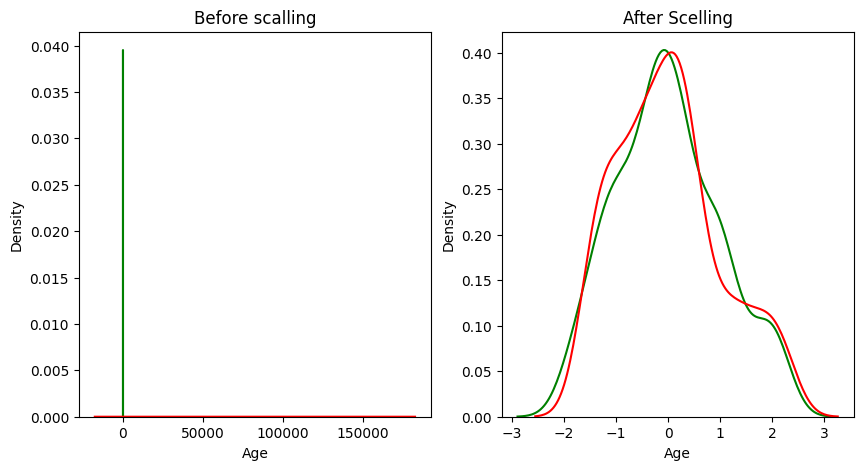

In [ ]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,5))

ax1.set_title("Before scalling")
sns.kdeplot(x_train['Age'],ax=ax1,color='green')
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1,color='red')

ax2.set_title("After Scelling")
sns.kdeplot(x_train_scaled['Age'],ax=ax2,color='green')
sns.kdeplot(x_train_scaled['EstimatedSalary'],ax=ax2,color='red')

# we are ploting probability density function graph
# Here we can see how actually scalling is helping us
# we can see after scalling both of the columns are comparable to each other 
# But when we didnt scale the Data we can see that we cant compare both columsn becuase the dristribution of the data is uncomparable

In [52]:
from sklearn.linear_model import LogisticRegression


In [60]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [66]:


lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [72]:
y_pred=lr.predict(x_train)
y_pred_scaled=lr_scaled.predict(x_train_scaled)

In [70]:
from sklearn.metrics import accuracy_score

In [74]:
print('Actual',accuracy_score(y_train,y_pred))
print('scaled',accuracy_score(y_train,y_pred_scaled))

Actual 0.8375
scaled 0.840625
